# vid-to-pol deconstruction

Notebook for training and inspecting the full pipeline on one small slice of data.

This notebook mirrors the implementation in `Student/src` as closely as possible, while keeping epochs/sample counts small enough for interactive debugging:

1. frames -> train autoencoder latent
2. trained autoencoder latents -> train LSTM prediction
3. trained autoencoder + trained LSTM context -> train Video Learner desired latent delta
4. trained autoencoder + env random real actions -> train Machine Forward real action to latent delta model
5. trained Video Learner + trained Machine Forward -> Runtime Control action search

## 0. Setup

In [ ]:
# =========================
# 0. Global setup / resources
# =========================
# Run this cell first. In Colab, set PROJECT_ROOT to the folder that contains `Student/`.
# Example:
#   from google.colab import drive
#   drive.mount("/content/drive")
#   PROJECT_ROOT = Path("/content/drive/MyDrive/vid-to-pol")

from pathlib import Path
import os
import sys
import time
import math
import random

# Matplotlib cache must be writable in Colab/local sandboxes.
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib"))

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split

# -------------------------
# Project roots
# -------------------------
PROJECT_ROOT = globals().get("PROJECT_ROOT", None)
if PROJECT_ROOT is None:
    cwd = Path.cwd().resolve()
    if (cwd / "Student" / "src").is_dir():
        PROJECT_ROOT = cwd
    elif cwd.name == "Student" and (cwd / "src").is_dir():
        PROJECT_ROOT = cwd.parent
    elif cwd.name == "research" and (cwd.parent / "src").is_dir():
        PROJECT_ROOT = cwd.parent.parent
    else:
        raise RuntimeError(
            "Could not locate project root. In Colab set PROJECT_ROOT to the folder containing Student/."
        )
else:
    PROJECT_ROOT = Path(PROJECT_ROOT).resolve()

STUDENT = PROJECT_ROOT / "Student"
SRC_DIR = STUDENT / "src"
FRAMES_DIR = STUDENT / "data" / "frames"
RUNS_DIR = STUDENT / "runs"
ACTION_RUNS_DIR = RUNS_DIR / "action_inference"

# -------------------------
# Required trained artifacts
# -------------------------
AE_MODEL_PATH = RUNS_DIR / "autoencoder" / "model.pth"
SEQ_MODEL_PATH = RUNS_DIR / "sequential" / "model.pth"
SEQ_TRAIN_PATH = RUNS_DIR / "sequential" / "seq_train_dataset.pt"
SEQ_TEST_PATH = RUNS_DIR / "sequential" / "seq_test_dataset.pt"

IDM_MODEL_PATH = ACTION_RUNS_DIR / "video_learner" / "idm_model.pth"
FDM_MODEL_PATH = ACTION_RUNS_DIR / "video_learner" / "fdm_model.pth"
MACHINE_PROBE_PATH = ACTION_RUNS_DIR / "machine_forward" / "machine_probe_dataset.pt"
MACHINE_MODEL_PATH = ACTION_RUNS_DIR / "machine_forward" / "machine_forward_model.pth"

RESOURCE_PATHS = {
    "frames_dir": FRAMES_DIR,
    "ae_model": AE_MODEL_PATH,
    "seq_model": SEQ_MODEL_PATH,
    "seq_train_dataset": SEQ_TRAIN_PATH,
    "seq_test_dataset": SEQ_TEST_PATH,
    "idm_model_optional": IDM_MODEL_PATH,
    "fdm_model_optional": FDM_MODEL_PATH,
    "machine_probe_optional": MACHINE_PROBE_PATH,
    "machine_model_optional": MACHINE_MODEL_PATH,
}

# -------------------------
# Python path / working dir
# -------------------------
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
os.chdir(STUDENT)

# -------------------------
# Reproducibility / device
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = get_device()

# -------------------------
# Notebook constants
# -------------------------
Z_DIM = 64
SEQ_LEN = 32
LATENT_A_DIM = 8
OVERLAY_DECAY = 0.9
REAL_A_DIM = 2

# -------------------------
# Resource check
# -------------------------
def print_resource_status(paths):
    for name, path in paths.items():
        exists = path.exists()
        kind = "dir" if path.is_dir() else "file"
        status = "OK" if exists else "MISSING"
        print(f"{status:7s} {name:24s} {kind:4s} {path}")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("STUDENT:", STUDENT)
print("SRC_DIR:", SRC_DIR)
print("DEVICE:", DEVICE)
print("\nResources:")
print_resource_status(RESOURCE_PATHS)


PROJECT_ROOT: /Users/adriankazi/Desktop/vid-to-pol
STUDENT: /Users/adriankazi/Desktop/vid-to-pol/Student
SRC_DIR: /Users/adriankazi/Desktop/vid-to-pol/Student/src
DEVICE: mps

Resources:
OK      frames_dir               dir  /Users/adriankazi/Desktop/vid-to-pol/Student/data/frames
OK      ae_model                 file /Users/adriankazi/Desktop/vid-to-pol/Student/runs/autoencoder/model.pth
OK      seq_model                file /Users/adriankazi/Desktop/vid-to-pol/Student/runs/sequential/model.pth
OK      seq_train_dataset        file /Users/adriankazi/Desktop/vid-to-pol/Student/runs/sequential/seq_train_dataset.pt
OK      seq_test_dataset         file /Users/adriankazi/Desktop/vid-to-pol/Student/runs/sequential/seq_test_dataset.pt
OK      idm_model_optional       file /Users/adriankazi/Desktop/vid-to-pol/Student/runs/action_inference/video_learner/idm_model.pth
OK      fdm_model_optional       file /Users/adriankazi/Desktop/vid-to-pol/Student/runs/action_inference/video_learner/fdm_mode

## 1. Import Data

Import only 10 episodes. This is research/debug mode, not full training.

In [173]:
def frame_sort_key(path: Path):
    try:
        return int(path.stem)
    except ValueError:
        return path.stem

all_episode_dirs = sorted(
    [p for p in FRAMES_DIR.iterdir() if p.is_dir()],
    key=lambda p: int(p.name) if p.name.isdigit() else p.name,
)

# Only 10 episodes for deconstruction.
episode_dirs = all_episode_dirs[:10]
episodes = []
for ep_dir in episode_dirs:
    frame_paths = sorted(ep_dir.glob("*.png"), key=frame_sort_key)
    if frame_paths:
        episodes.append(frame_paths)

print("episodes loaded:", len(episodes))
for i, ep in enumerate(episodes):
    print(f"episode[{i}] dir={ep[0].parent.name} frames={len(ep)} first={ep[0].name} last={ep[-1].name}")

episodes loaded: 10
episode[0] dir=0 frames=512 first=0.png last=511.png
episode[1] dir=1 frames=233 first=0.png last=232.png
episode[2] dir=2 frames=437 first=0.png last=436.png
episode[3] dir=3 frames=260 first=0.png last=259.png
episode[4] dir=4 frames=253 first=0.png last=252.png
episode[5] dir=5 frames=344 first=0.png last=343.png
episode[6] dir=6 frames=251 first=0.png last=250.png
episode[7] dir=7 frames=349 first=0.png last=348.png
episode[8] dir=8 frames=408 first=0.png last=407.png
episode[9] dir=9 frames=301 first=0.png last=300.png


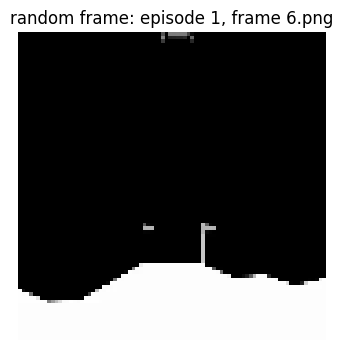

In [174]:
# Plot one random raw frame.
ep = random.choice(episodes)
frame_path = random.choice(ep)
img = Image.open(frame_path).convert("RGB")

plt.figure(figsize=(5, 4))
plt.imshow(img)
plt.title(f"random frame: episode {frame_path.parent.name}, frame {frame_path.name}")
plt.axis("off")
plt.show()

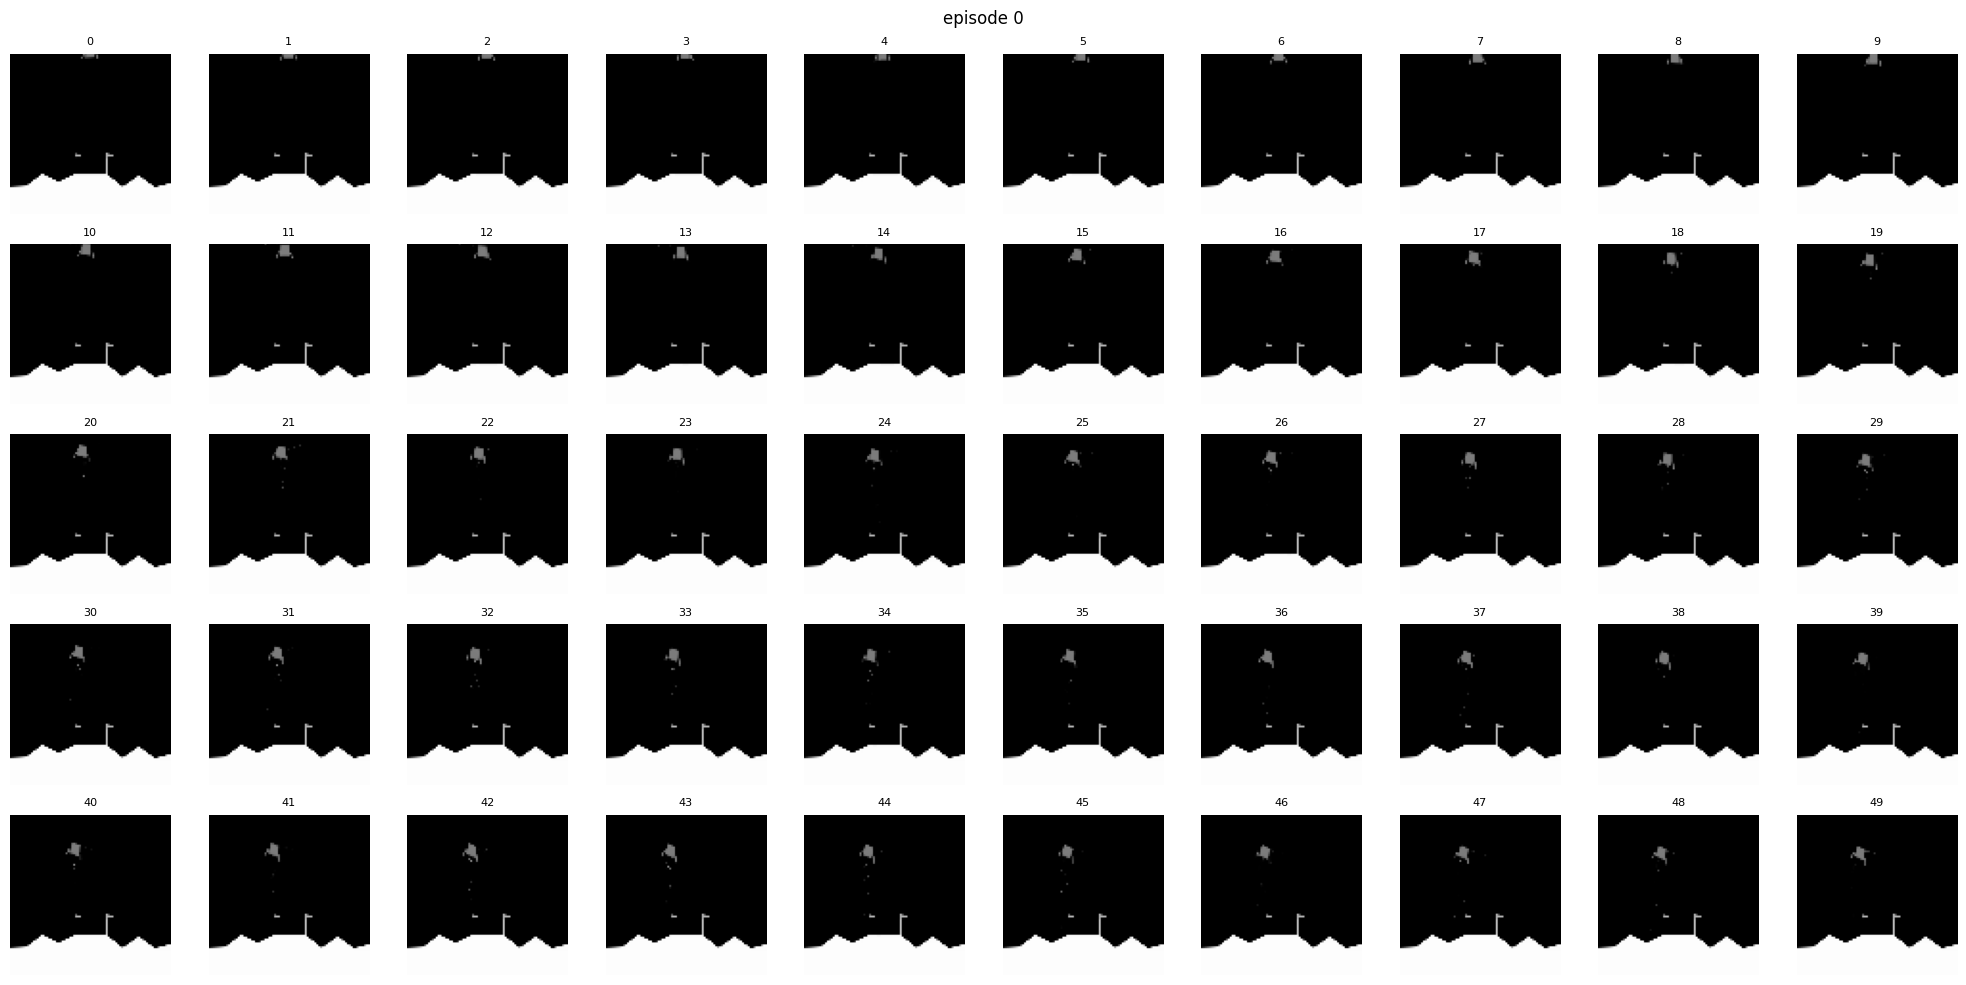

In [175]:
def load_frame_tensor(path: Path, size=(84, 84)):
    # PNG/RGB frame -> torch tensor (1,1,84,84), values in [0,1].
    img = Image.open(path).convert("L").resize(size)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return torch.from_numpy(arr)[None, None]

def show_episode(ep, max_frames=None, cols=10, title=None):
    paths = ep if max_frames is None else ep[:max_frames]
    rows = math.ceil(len(paths) / cols)
    fig, axs = plt.subplots(rows, cols, figsize=(2.0 * cols, 2.0 * rows))
    axs = np.asarray(axs).reshape(-1)
    for ax in axs:
        ax.axis("off")
    for ax, path in zip(axs, paths):
        ax.imshow(Image.open(path).convert("RGB"))
        ax.set_title(path.stem, fontsize=8)
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

# One episode, 10 frames per row.
show_episode(episodes[0], max_frames=min(len(episodes[0]), 50), cols=10, title=f"episode {episodes[0][0].parent.name}")

## 2. Load Autoencoder and LSTM

The Autoencoder and Sequential LSTM are **not trained in this notebook**. They are loaded from existing project artifacts:

- `Student/runs/autoencoder/model.pth`
- `Student/runs/sequential/model.pth`
- `Student/runs/sequential/seq_train_dataset.pt`
- `Student/runs/sequential/seq_test_dataset.pt`

The notebook trains/inspects the later Action Inference pieces on top of those frozen models.

### 2.1 Autoencoder

In [176]:
from Autoencoder.config import AutoencoderConfig
from Autoencoder.network import AutoEncoder
from Sequential.config import SequentialConfig

AE_CFG = AutoencoderConfig()
SEQ_CFG = SequentialConfig()

Z_DIM = AE_CFG.z_dim
SEQ_LEN = SEQ_CFG.seq_len

AE_MODEL_PATH = STUDENT / "runs" / "autoencoder" / "model.pth"
SEQ_MODEL_PATH = STUDENT / "runs" / "sequential" / "model.pth"
SEQ_TRAIN_PATH = STUDENT / "runs" / "sequential" / "seq_train_dataset.pt"
SEQ_TEST_PATH = STUDENT / "runs" / "sequential" / "seq_test_dataset.pt"

for required_path in [AE_MODEL_PATH, SEQ_MODEL_PATH, SEQ_TRAIN_PATH, SEQ_TEST_PATH]:
    if not required_path.is_file():
        raise FileNotFoundError(required_path)

ae = AutoEncoder(z_dim=Z_DIM).to(DEVICE)
ae.load_state_dict(torch.load(AE_MODEL_PATH, map_location=DEVICE))
ae.eval()
for p in ae.parameters():
    p.requires_grad = False

print("loaded AE:", AE_MODEL_PATH)
print("Z_DIM:", Z_DIM, "SEQ_LEN:", SEQ_LEN)

loaded AE: /Users/adriankazi/Desktop/vid-to-pol/Student/runs/autoencoder/model.pth
Z_DIM: 64 SEQ_LEN: 32


In [177]:
# No AE training here. Use the trained checkpoint from Student/runs/autoencoder.
ae_losses_path = STUDENT / "runs" / "autoencoder" / "losses.pt"
if ae_losses_path.is_file():
    ae_losses = torch.load(ae_losses_path, map_location="cpu")
    print("AE saved loss keys:", list(ae_losses.keys()))
else:
    ae_losses = None
    print("No AE losses.pt found; continuing with loaded model only.")

AE saved loss keys: ['ae_train_losses', 'ae_test_losses']


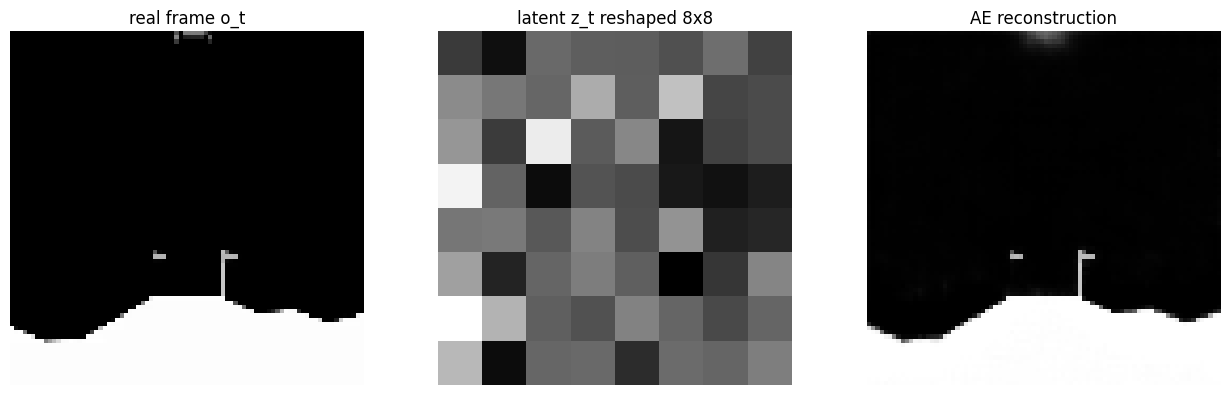

reconstruction MSE: 0.0006179201882332563
latent norm: 8.034815788269043


In [178]:
# Autoencoder visual check: real frame, latent grid, reconstruction.
x = load_frame_tensor(frame_path).to(DEVICE)
with torch.no_grad():
    x_hat, z = ae(x)

real = x[0, 0].detach().cpu().numpy()
recon = x_hat[0, 0].detach().cpu().numpy()
latent_grid = z[0].detach().cpu().view(8, 8).numpy()

fig, axs = plt.subplots(1, 3, figsize=(13, 4))
axs[0].imshow(real, cmap="gray")
axs[0].set_title("real frame o_t")
axs[0].axis("off")

axs[1].imshow(latent_grid, cmap="gray")
axs[1].set_title("latent z_t reshaped 8x8")
axs[1].axis("off")

axs[2].imshow(recon, cmap="gray")
axs[2].set_title("AE reconstruction")
axs[2].axis("off")

plt.tight_layout()
plt.show()
print("reconstruction MSE:", float(F.mse_loss(x_hat, x).detach().cpu()))
print("latent norm:", float(z.norm().detach().cpu()))

### 2.2 Sequential LSTM

The LSTM is loaded from `Student/runs/sequential/model.pth`; it is not trained here.

In [179]:
from Sequential.network import LatentLSTM

lstm = LatentLSTM(
    z_dim=Z_DIM,
    hidden_dim=SEQ_CFG.hidden_dim,
    num_layers=SEQ_CFG.num_layers,
    dropout=SEQ_CFG.dropout,
).to(DEVICE)
lstm.load_state_dict(torch.load(SEQ_MODEL_PATH, map_location=DEVICE))
lstm.eval()
for p in lstm.parameters():
    p.requires_grad = False

print("loaded LSTM:", SEQ_MODEL_PATH)

loaded LSTM: /Users/adriankazi/Desktop/vid-to-pol/Student/runs/sequential/model.pth


In [180]:
# Load the exact Sequential datasets produced by Student/src/Sequential/build_dataset.py.
SEQ_MAX_CHUNKS = 256
SEQ_BATCH_SIZE = 16

seq_train_data_full = torch.load(SEQ_TRAIN_PATH, map_location="cpu")
seq_test_data_full = torch.load(SEQ_TEST_PATH, map_location="cpu")


def limit_seq_data_evenly(data, max_chunks=None):
    n = int(data["x"].shape[0])
    if max_chunks is None or n <= max_chunks:
        return data
    idxs = torch.linspace(0, n - 1, max_chunks).long()
    return {
        "x": data["x"][idxs],
        "lengths": data["lengths"][idxs],
        "episode_ids": data["episode_ids"][idxs],
        "seq_len": data.get("seq_len", SEQ_LEN),
    }

seq_train_data = limit_seq_data_evenly(seq_train_data_full, SEQ_MAX_CHUNKS)
seq_test_data = limit_seq_data_evenly(seq_test_data_full, max(1, SEQ_MAX_CHUNKS // 4))


def encode_frame_sequence(x_seq):
    # x_seq: (1,T,1,84,84) -> (1,T,Z_DIM)
    zs = []
    with torch.no_grad():
        for t in range(x_seq.shape[1]):
            _, z_t = ae(x_seq[:, t])
            zs.append(z_t)
    return torch.stack(zs, dim=1)


def encode_frame_batch(x_bt):
    # x_bt: (B,T,1,84,84) -> (B,T,Z_DIM)
    zs = []
    with torch.no_grad():
        for t in range(x_bt.shape[1]):
            _, z_t = ae(x_bt[:, t])
            zs.append(z_t)
    return torch.stack(zs, dim=1)

print("loaded seq train:", SEQ_TRAIN_PATH)
print("loaded seq test:", SEQ_TEST_PATH)
print("seq train x:", tuple(seq_train_data["x"].shape), "full:", tuple(seq_train_data_full["x"].shape))
print("seq test x:", tuple(seq_test_data["x"].shape), "full:", tuple(seq_test_data_full["x"].shape))
print("mean train valid length:", float(seq_train_data["lengths"].float().mean()))

loaded seq train: /Users/adriankazi/Desktop/vid-to-pol/Student/runs/sequential/seq_train_dataset.pt
loaded seq test: /Users/adriankazi/Desktop/vid-to-pol/Student/runs/sequential/seq_test_dataset.pt
seq train x: (256, 32, 1, 84, 84) full: (3023, 32, 1, 84, 84)
seq test x: (64, 32, 1, 84, 84) full: (827, 32, 1, 84, 84)
mean train valid length: 29.62890625


In [181]:
def first_valid_chunk(data, min_len=2):
    for i in range(int(data["x"].shape[0])):
        valid_len = int(data["lengths"][i].item())
        if valid_len >= min_len:
            return data["x"][i, :valid_len], valid_len, int(data["episode_ids"][i].item())
    raise ValueError(f"No chunk with >= {min_len} valid frames")

chunk, valid_len, seq_ep_id = first_valid_chunk(seq_test_data, min_len=2)
x_hist = chunk[:-1].to(DEVICE)  # (T-1,1,84,84)
x_next = chunk[-1:].to(DEVICE)  # (1,1,84,84)

with torch.no_grad():
    z_hist = encode_frame_sequence(x_hist[None])
    z_next_true = ae(x_next)[1]
    z_next_pred = lstm(z_hist, lengths=torch.tensor([z_hist.shape[1]], dtype=torch.int64, device=DEVICE))
    x_next_pred = ae.decode(z_next_pred)

print("src-like reduced episode id:", seq_ep_id)
print("valid chunk length:", valid_len)
print("history len:", x_hist.shape[0])
print("next latent MSE:", float(F.mse_loss(z_next_pred, z_next_true).detach().cpu()))

src-like reduced episode id: 0
valid chunk length: 32
history len: 31
next latent MSE: 0.007314467802643776


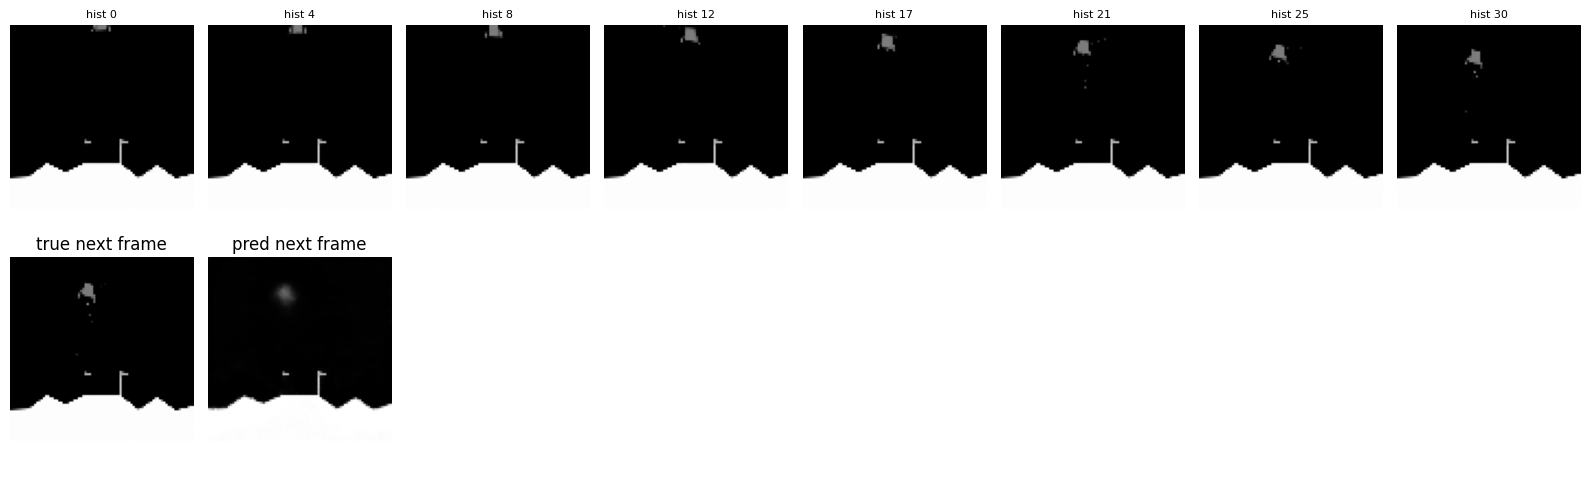

In [182]:
# LSTM visual check: short history preview + true next + predicted next.
preview_idx = torch.linspace(0, x_hist.shape[0] - 1, min(8, x_hist.shape[0])).long().tolist()
fig, axs = plt.subplots(2, 8, figsize=(16, 5))
axs = np.asarray(axs)

for ax in axs.reshape(-1):
    ax.axis("off")

for i, idx in enumerate(preview_idx):
    axs[0, i].imshow(x_hist[idx, 0].detach().cpu(), cmap="gray")
    axs[0, i].set_title(f"hist {idx}", fontsize=8)

axs[1, 0].imshow(x_next[0, 0].detach().cpu(), cmap="gray")
axs[1, 0].set_title("true next frame")

axs[1, 1].imshow(x_next_pred[0, 0].detach().cpu(), cmap="gray")
axs[1, 1].set_title("pred next frame")

plt.tight_layout()
plt.show()

## 3. Action Inference

The action system is three pieces:

1. **Video Learner**: from video context, infer desired latent movement.
2. **Machine Forward**: from real action, predict latent movement caused by that action.
3. **Runtime Control**: search real actions whose Machine Forward delta matches Video Learner desired delta.

### 3.1 Video Learner

Video Learner models are defined inline here:

- `IDMModel(c_t) -> latent action`
- `FDMModel(c_t, latent_action) -> desired latent delta`
- `c_t = [z_t, h_t, m_t]`

Where:

- `z_t`: current autoencoder latent
- `h_t`: LSTM hidden state after the history
- `m_t`: autoencoder latent of an exponentially weighted frame overlay

| Intuitive description | Formula |
|---|---|
| Take expert video history. | $o_{t-k:t}$ |
| Encode frames into latents. | $z_{t-k:t}=AE(o_{t-k:t})$ |
| Current latent is the last history latent. | $z_t=z_{t}$ |
| Encode temporal history with frozen LSTM. | $h_t=LSTM(z_{t-k:t})$ |
| Build motion overlay from video frames. | $m_t=AE(Overlay(o_{t-k:t}))$ |
| Build video context. | $c_t=[z_t,h_t,m_t]$ |
| Infer latent pseudo-action from video context. | $\ell_t=IDM(c_t)$ |
| Predict desired latent movement. | $\Delta z^{desired}_{t+1}=FDM(c_t,\ell_t)$ |
| Reconstruct predicted next latent. | $\hat z_{t+1}=z_t+\Delta z^{desired}_{t+1}$ |
| Training target is observed video movement. | $\Delta z^{video}_{t+1}=z_{t+1}-z_t$ |
| Video Learner loss. | $\mathcal{L}_{VL}=\|\hat z_{t+1}-z_{t+1}\|^2$ |

Important: this model does **not** know expert actions. It learns a latent pseudo-action $\ell_t$ that explains the movement observed in expert video.

#### 3.1.1 Model

In [183]:
LATENT_A_DIM = 8
OVERLAY_DECAY = 0.9


def overlay_frames(x_seq, decay=0.9):
    # x_seq: (B,T,1,84,84)
    T = x_seq.shape[1]
    weights = torch.tensor(
        [decay ** (T - 1 - i) for i in range(T)],
        device=x_seq.device,
        dtype=x_seq.dtype,
    )
    weights = weights / weights.sum()
    return (x_seq * weights.view(1, T, 1, 1, 1)).sum(dim=1)


class IDMModel(nn.Module):
    def __init__(self, c_dim, latent_a_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(c_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Linear(128, latent_a_dim),
            nn.Tanh(),
        )

    def forward(self, c_t):
        return self.net(c_t)


class FDMModel(nn.Module):
    def __init__(self, c_dim, z_dim=64, latent_a_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(c_dim + latent_a_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Linear(256, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Linear(128, z_dim),
        )

    def forward(self, c_t, latent_a):
        x = torch.cat([c_t, latent_a], dim=-1)
        return self.net(x)


# c_t = [z_t, h_t, m_t]
# z_t: 64, h_t: 256, m_t: 64 -> C_DIM = 384
with torch.no_grad():
    x0 = seq_train_data["x"][:1].to(DEVICE)
    x_hist0 = x0[:, :-1]
    z_hist0 = encode_frame_batch(x_hist0)
    z_t0 = z_hist0[:, -1]
    h_seq0, _ = lstm.lstm(z_hist0)
    h_t0 = h_seq0[:, -1, :]
    _, m_t0 = ae(overlay_frames(x_hist0, decay=OVERLAY_DECAY))
    c_t0 = torch.cat([z_t0, h_t0, m_t0], dim=-1)

C_DIM = c_t0.shape[-1]
idm = IDMModel(c_dim=C_DIM, latent_a_dim=LATENT_A_DIM).to(DEVICE)
fdm = FDMModel(c_dim=C_DIM, z_dim=Z_DIM, latent_a_dim=LATENT_A_DIM).to(DEVICE)

print("C_DIM:", C_DIM)
print(idm)
print(fdm)

C_DIM: 384
IDMModel(
  (net): Sequential(
    (0): Linear(in_features=384, out_features=512, bias=True)
    (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=512, out_features=512, bias=True)
    (4): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (8): GELU(approximate='none')
    (9): Linear(in_features=256, out_features=128, bias=True)
    (10): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (11): GELU(approximate='none')
    (12): Linear(in_features=128, out_features=8, bias=True)
    (13): Tanh()
  )
)
FDMModel(
  (net): Sequential(
    (0): Linear(in_features=392, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=256, out_features=

#### 3.1.2 Train

Video Learner chunks: 256 train: 205 test: 51 batch: 32
[VideoLearner] epoch 001/10 train=0.057223 test=0.049167 z=0.057223 delta=0.057223 cos=-0.0057 lstm=0.031472 latent_std=0.2231 elapsed=10.7s
[VideoLearner] epoch 002/10 train=0.007553 test=0.039276 z=0.007553 delta=0.007553 cos=0.0160 lstm=0.031472 latent_std=0.2211 elapsed=21.5s
[VideoLearner] epoch 003/10 train=0.002395 test=0.037368 z=0.002395 delta=0.002395 cos=0.0216 lstm=0.031472 latent_std=0.1897 elapsed=31.9s
[VideoLearner] epoch 004/10 train=0.001554 test=0.036526 z=0.001554 delta=0.001554 cos=0.0331 lstm=0.031472 latent_std=0.1654 elapsed=42.5s
[VideoLearner] epoch 005/10 train=0.000874 test=0.036142 z=0.000874 delta=0.000874 cos=0.0389 lstm=0.031472 latent_std=0.1516 elapsed=53.2s
[VideoLearner] epoch 006/10 train=0.000531 test=0.035885 z=0.000531 delta=0.000531 cos=0.0323 lstm=0.031472 latent_std=0.1456 elapsed=63.7s
[VideoLearner] epoch 007/10 train=0.000427 test=0.035960 z=0.000427 delta=0.000427 cos=0.0556 lstm=0.03

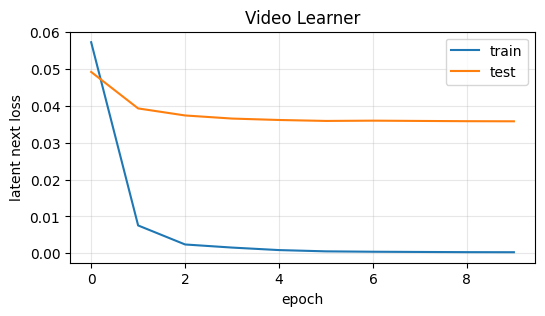

In [184]:
VL_EPOCHS = 10
VL_BATCH_SIZE = 32
VL_LR = 3e-4

# Match src/ActionInference/video_learner/train.py: train directly on seq_train_data["x"].
n_total = seq_train_data["x"].shape[0]
n_test = max(1, int(0.2 * n_total))
n_train = n_total - n_test

split_gen = torch.Generator().manual_seed(SEED)
perm = torch.randperm(n_total, generator=split_gen)

train_x = seq_train_data["x"][perm[:n_train]]
test_x = seq_train_data["x"][perm[n_train:]]

vl_train_loader = DataLoader(TensorDataset(train_x), batch_size=VL_BATCH_SIZE, shuffle=True)
vl_test_loader = DataLoader(TensorDataset(test_x), batch_size=VL_BATCH_SIZE, shuffle=False)

for p in lstm.parameters():
    p.requires_grad = False
lstm.eval()

@torch.no_grad()
def lstm_hidden_and_next(lstm_model, z_seq):
    h_seq, _ = lstm_model.lstm(z_seq)
    h_t = h_seq[:, -1, :]
    z_next = lstm_model(z_seq)
    if isinstance(z_next, tuple):
        z_next = z_next[-1]
    return h_t, z_next

@torch.no_grad()
def build_video_context(x):
    # x: (B,SEQ_LEN,1,84,84)
    x_input = x[:, :-1]
    x_target = x[:, -1]
    x_overlay = overlay_frames(x_input, decay=OVERLAY_DECAY)
    _, m_t = ae(x_overlay)
    z_input = encode_frame_batch(x_input)
    z_t = z_input[:, -1]
    _, z_true_next = ae(x_target)
    true_delta = z_true_next - z_t
    h_t, z_lstm_next = lstm_hidden_and_next(lstm, z_input)
    c_t = torch.cat([z_t, h_t, m_t], dim=-1)
    return c_t, z_t, z_true_next, true_delta, z_lstm_next

vl_opt = torch.optim.Adam(list(idm.parameters()) + list(fdm.parameters()), lr=VL_LR)
vl_train_losses = []
vl_test_losses = []
vl_delta_cos = []
vl_lstm_baseline = []
vl_latent_a_std = []

print("Video Learner chunks:", n_total, "train:", n_train, "test:", n_test, "batch:", VL_BATCH_SIZE)

t0 = time.time()
for epoch in range(1, VL_EPOCHS + 1):
    idm.train(); fdm.train()
    sums = {
        "total": 0.0,
        "z": 0.0,
        "delta": 0.0,
        "delta_cos": 0.0,
        "lstm_baseline": 0.0,
        "latent_a_std": 0.0,
    }
    train_n = 0

    for (x,) in vl_train_loader:
        x = x.to(DEVICE)
        c_t, z_t, z_true_next, true_delta, z_lstm_next = build_video_context(x)
        latent_a = idm(c_t)
        pred_delta = fdm(c_t, latent_a)
        pred_next = z_t + pred_delta

        loss_z = F.mse_loss(pred_next, z_true_next)
        loss_delta = F.mse_loss(pred_delta, true_delta)
        cos_delta = F.cosine_similarity(pred_delta, true_delta, dim=-1).mean()
        loss_lstm = F.mse_loss(z_lstm_next, z_true_next)
        loss = loss_z

        vl_opt.zero_grad(set_to_none=True)
        loss.backward()
        vl_opt.step()

        bs = x.shape[0]
        sums["total"] += float(loss.item()) * bs
        sums["z"] += float(loss_z.item()) * bs
        sums["delta"] += float(loss_delta.item()) * bs
        sums["delta_cos"] += float(cos_delta.item()) * bs
        sums["lstm_baseline"] += float(loss_lstm.item()) * bs
        sums["latent_a_std"] += float(latent_a.std(dim=0, unbiased=False).mean().item()) * bs
        train_n += bs

    means = {k: v / max(train_n, 1) for k, v in sums.items()}

    idm.eval(); fdm.eval()
    test_sum = 0.0
    test_n = 0
    with torch.no_grad():
        for (x,) in vl_test_loader:
            x = x.to(DEVICE)
            c_t, z_t, z_true_next, true_delta, _ = build_video_context(x)
            latent_a = idm(c_t)
            pred_delta = fdm(c_t, latent_a)
            pred_next = z_t + pred_delta
            loss = F.mse_loss(pred_next, z_true_next)
            test_sum += float(loss.item()) * x.shape[0]
            test_n += x.shape[0]

    test_loss = test_sum / max(test_n, 1)
    vl_train_losses.append(means["total"])
    vl_test_losses.append(test_loss)
    vl_delta_cos.append(means["delta_cos"])
    vl_lstm_baseline.append(means["lstm_baseline"])
    vl_latent_a_std.append(means["latent_a_std"])

    print(
        f"[VideoLearner] epoch {epoch:03d}/{VL_EPOCHS} "
        f"train={means['total']:.6f} test={test_loss:.6f} "
        f"z={means['z']:.6f} delta={means['delta']:.6f} "
        f"cos={means['delta_cos']:.4f} lstm={means['lstm_baseline']:.6f} "
        f"latent_std={means['latent_a_std']:.4f} elapsed={time.time() - t0:.1f}s"
    )

idm.eval(); fdm.eval()
plt.figure(figsize=(6, 3))
plt.plot(vl_train_losses, label="train")
plt.plot(vl_test_losses, label="test")
plt.title("Video Learner")
plt.xlabel("epoch")
plt.ylabel("latent next loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

#### 3.1.3 Deconstruct

`episode` = the full video  
`chunk` = a short fixed-length part of the video

Example:

`episode_0` has `100` frames.

We split it into chunks of `SEQ_LEN = 32` frames:

`chunk_0 = frames 0-31`  
`chunk_1 = frames 32-63`  
`chunk_2 = frames 64-95`  
`chunk_3 = frames 96-99 + padding up to 32 frames`

So:

`episode` = whole video  
`chunk` = `32`-frame segment from that video

Then all chunks from all episodes are collected into `seq_train_data["x"]`.

$$
\text{seq\_train\_data}["x"].shape = (N, 32, 1, 84, 84)
$$

#### 3.1.3 Eval

In [185]:
@torch.no_grad()
def video_learner_step(x_hist, x_next):
    # x_hist: (T,1,84,84), x_next: (1,1,84,84)
    x_seq = x_hist[None]  # (1,T,1,84,84)
    z_hist_local = encode_frame_batch(x_seq)
    z_t = z_hist_local[:, -1]
    z_next_true = ae(x_next)[1]
    true_delta = z_next_true - z_t

    h_t, lstm_next = lstm_hidden_and_next(lstm, z_hist_local)
    x_overlay = overlay_frames(x_seq, decay=OVERLAY_DECAY)
    overlay_recon, m_t = ae(x_overlay)
    c_t = torch.cat([z_t, h_t, m_t], dim=-1)
    latent_action = idm(c_t)
    desired_delta = fdm(c_t, latent_action)
    pred_next = z_t + desired_delta

    return {
        "x_seq": x_seq,
        "z_hist": z_hist_local,
        "z_t": z_t,
        "z_next_true": z_next_true,
        "true_delta": true_delta,
        "h_t": h_t,
        "x_overlay": x_overlay,
        "overlay_recon": overlay_recon,
        "m_t": m_t,
        "c_t": c_t,
        "latent_action": latent_action,
        "desired_delta": desired_delta,
        "pred_next": pred_next,
    }

vl = video_learner_step(x_hist, x_next)
print("context shape:", tuple(vl["c_t"].shape))
print("latent action:", vl["latent_action"].detach().cpu().numpy().round(4))
print("desired delta norm:", float(vl["desired_delta"].norm().detach().cpu()))
print("true delta norm:", float(vl["true_delta"].norm().detach().cpu()))
print("VL delta MSE:", float(F.mse_loss(vl["desired_delta"], vl["true_delta"]).detach().cpu()))

context shape: (1, 384)
latent action: [[ 0.4259  0.8273  0.6405  0.8203 -0.9314 -0.8978 -0.8106  0.0535]]
desired delta norm: 0.13157658278942108
true delta norm: 0.14503948390483856
VL delta MSE: 0.0005317397881299257


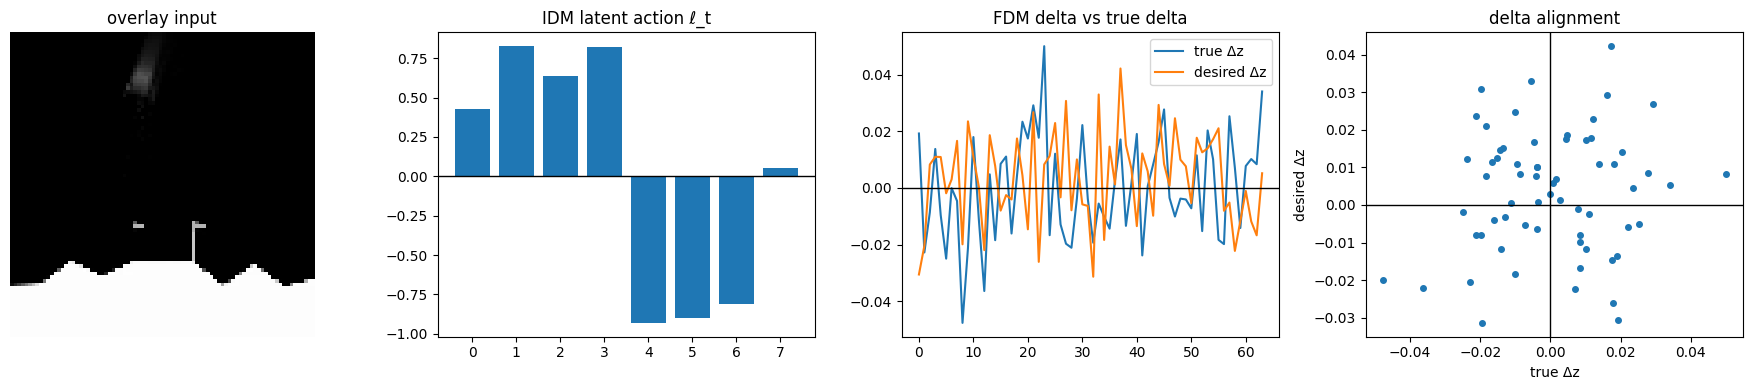

In [186]:
# Video Learner visualization.
true_delta = vl["true_delta"][0].detach().cpu().numpy()
desired_delta = vl["desired_delta"][0].detach().cpu().numpy()
latent_action = vl["latent_action"][0].detach().cpu().numpy()

fig, axs = plt.subplots(1, 4, figsize=(18, 4))
axs[0].imshow(vl["x_overlay"][0, 0].detach().cpu(), cmap="gray")
axs[0].set_title("overlay input")
axs[0].axis("off")

axs[1].bar(np.arange(LATENT_A_DIM), latent_action)
axs[1].axhline(0, color="black", lw=1)
axs[1].set_title("IDM latent action ℓ_t")

axs[2].plot(true_delta, label="true Δz")
axs[2].plot(desired_delta, label="desired Δz")
axs[2].axhline(0, color="black", lw=1)
axs[2].set_title("FDM delta vs true delta")
axs[2].legend()

axs[3].scatter(true_delta, desired_delta, s=16)
axs[3].axhline(0, color="black", lw=1)
axs[3].axvline(0, color="black", lw=1)
axs[3].set_xlabel("true Δz")
axs[3].set_ylabel("desired Δz")
axs[3].set_title("delta alignment")

plt.tight_layout()
plt.show()

### 3.2 Machine Forward

| Intuitive description | Formula |
|---|---|
| Sample a real action from LunarLander action space. | $a_t\in[-1,1]^2$ |
| Apply action in the environment and observe next frame. | $o_{t+s}=Env(o_t,a_t)$ |
| Encode current and next frame. | $z_t=AE(o_t),\;z_{t+s}=AE(o_{t+s})$ |
| Training target is the real latent movement caused by that action. | $\Delta z^{env}_{t+s}=z_{t+s}-z_t$ |
| Encode machine history. | $u_t=LSTM_{MF}(z_{t-k:t})$ |
| Predict action-conditioned latent movement. | $\Delta z^{machine}_{t+s}=MF(u_t,a_t)$ |
| Machine Forward loss. | $\mathcal{L}_{MF}=\|\Delta z^{machine}_{t+s}-\Delta z^{env}_{t+s}\|^2$ |

Important: this model does **not** know expert actions. It learns how random real actions move latent space.

In [187]:
from ActionInference.machine_forward.models import MachineForwardModel

MACHINE_HIST_LEN = 8
machine_forward = MachineForwardModel(z_dim=Z_DIM, real_a_dim=2, hidden_dim=256, num_layers=1).to(DEVICE)
print(machine_forward)

MachineForwardModel(
  (history_encoder): LSTM(64, 256, batch_first=True)
  (head): Sequential(
    (0): LayerNorm((258,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=258, out_features=256, bias=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): GELU(approximate='none')
    (5): Linear(in_features=256, out_features=64, bias=True)
  )
)


[MachineDataset] episode 001/3 samples=62
[MachineDataset] episode 002/3 samples=129
[MachineDataset] episode 003/3 samples=141
machine z_hist: (141, 8, 64)
machine a_real: (141, 2)
machine dz: (141, 64)
mean stride: 2.1063830852508545
[MachineForward] epoch 001/5 train=0.004940 test=0.002783 zero=0.000893 elapsed=0.0s
[MachineForward] epoch 002/5 train=0.002748 test=0.001981 zero=0.000893 elapsed=0.0s
[MachineForward] epoch 003/5 train=0.001922 test=0.001722 zero=0.000893 elapsed=0.0s
[MachineForward] epoch 004/5 train=0.001612 test=0.001576 zero=0.000893 elapsed=0.0s
[MachineForward] epoch 005/5 train=0.001433 test=0.001433 zero=0.000893 elapsed=0.1s


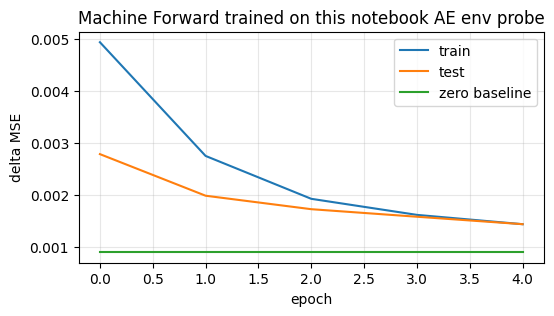

In [188]:
MACHINE_PROBE_EPISODES = 3
MACHINE_PROBE_MAX_STEPS = 80
MACHINE_MAX_STRIDE = 8
MACHINE_MIN_DELTA_NORM = 0.15
MACHINE_EPOCHS = 5
MACHINE_BATCH_SIZE = 128
MACHINE_LR = 3e-4


def preprocess_rgb(frame):
    img = Image.fromarray(frame).convert("L").resize((84, 84))
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return torch.from_numpy(arr)[None, None]


def sample_random_action(real_a_dim=2):
    return np.random.uniform(-1.0, 1.0, size=(real_a_dim,)).astype(np.float32)


def build_machine_probe_dataset_from_env():
    try:
        import gymnasium as gym
    except ImportError as exc:
        raise ImportError(
            "Machine Forward needs gymnasium with LunarLanderContinuous-v3 in this notebook, "
            "because real actions are not present in the frame folders. Install the project env/deps and rerun this cell."
        ) from exc

    env = gym.make("LunarLanderContinuous-v3", render_mode="rgb_array")
    z_hist_list = []
    a_list = []
    dz_list = []
    stride_list = []

    ae.eval()
    for ep_idx in range(MACHINE_PROBE_EPISODES):
        env.reset(seed=SEED + ep_idx)
        z_buffer = []
        rgb = env.render()
        x = preprocess_rgb(rgb).to(DEVICE)
        with torch.no_grad():
            _, z = ae(x)
        z_buffer.append(z.squeeze(0).detach().cpu())

        for step_idx in range(MACHINE_PROBE_MAX_STEPS):
            a_real_np = sample_random_action(2)
            z_t = z_buffer[-1].to(DEVICE)
            terminated = False
            truncated = False
            z_next = None
            used_stride = 0

            for _ in range(MACHINE_MAX_STRIDE):
                _, _, terminated, truncated, _ = env.step(a_real_np)
                used_stride += 1
                rgb_next = env.render()
                x_next = preprocess_rgb(rgb_next).to(DEVICE)
                with torch.no_grad():
                    _, z_next_batch = ae(x_next)
                z_next = z_next_batch.squeeze(0)
                delta_norm = torch.linalg.vector_norm(z_next - z_t).item()
                if delta_norm >= MACHINE_MIN_DELTA_NORM or terminated or truncated:
                    break

            dz = z_next - z_t
            hist = z_buffer
            if len(hist) < MACHINE_HIST_LEN:
                hist = [hist[0]] * (MACHINE_HIST_LEN - len(hist)) + hist
            else:
                hist = hist[-MACHINE_HIST_LEN:]

            z_hist_list.append(torch.stack(hist, dim=0).float())
            a_list.append(torch.from_numpy(a_real_np).float())
            dz_list.append(dz.detach().cpu().float())
            stride_list.append(used_stride)
            z_buffer.append(z_next.detach().cpu())
            z_buffer = z_buffer[-MACHINE_HIST_LEN:]

            if terminated or truncated:
                break

        print(f"[MachineDataset] episode {ep_idx + 1:03d}/{MACHINE_PROBE_EPISODES} samples={len(z_hist_list)}")

    env.close()
    if not z_hist_list:
        raise RuntimeError("Machine probe dataset is empty")

    return {
        "z_hist": torch.stack(z_hist_list),
        "a_real": torch.stack(a_list),
        "dz": torch.stack(dz_list),
        "stride": torch.tensor(stride_list, dtype=torch.int32),
    }

machine_probe = build_machine_probe_dataset_from_env()
print("machine z_hist:", tuple(machine_probe["z_hist"].shape))
print("machine a_real:", tuple(machine_probe["a_real"].shape))
print("machine dz:", tuple(machine_probe["dz"].shape))
print("mean stride:", float(machine_probe["stride"].float().mean()))

machine_ds = TensorDataset(machine_probe["z_hist"], machine_probe["a_real"], machine_probe["dz"])
n_test = max(1, int(0.2 * len(machine_ds)))
n_train = len(machine_ds) - n_test
machine_train_ds, machine_test_ds = random_split(
    machine_ds,
    [n_train, n_test],
    generator=torch.Generator().manual_seed(SEED),
)
machine_train_loader = DataLoader(machine_train_ds, batch_size=MACHINE_BATCH_SIZE, shuffle=True)
machine_test_loader = DataLoader(machine_test_ds, batch_size=MACHINE_BATCH_SIZE, shuffle=False)

machine_opt = torch.optim.Adam(machine_forward.parameters(), lr=MACHINE_LR)
machine_train_losses = []
machine_test_losses = []
machine_zero_losses = []

t0 = time.time()
for epoch in range(1, MACHINE_EPOCHS + 1):
    machine_forward.train()
    train_sum = 0.0
    train_n = 0
    for z_hist_b, a_b, dz_b in machine_train_loader:
        z_hist_b = z_hist_b.to(DEVICE)
        a_b = a_b.to(DEVICE)
        dz_b = dz_b.to(DEVICE)
        dz_pred = machine_forward(z_hist_b, a_b)
        loss = F.mse_loss(dz_pred, dz_b)
        machine_opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(machine_forward.parameters(), 1.0)
        machine_opt.step()
        train_sum += float(loss.item()) * z_hist_b.shape[0]
        train_n += z_hist_b.shape[0]

    machine_forward.eval()
    test_sum = 0.0
    zero_sum = 0.0
    test_n = 0
    with torch.no_grad():
        for z_hist_b, a_b, dz_b in machine_test_loader:
            z_hist_b = z_hist_b.to(DEVICE)
            a_b = a_b.to(DEVICE)
            dz_b = dz_b.to(DEVICE)
            dz_pred = machine_forward(z_hist_b, a_b)
            loss = F.mse_loss(dz_pred, dz_b)
            zero_loss = F.mse_loss(torch.zeros_like(dz_b), dz_b)
            test_sum += float(loss.item()) * z_hist_b.shape[0]
            zero_sum += float(zero_loss.item()) * z_hist_b.shape[0]
            test_n += z_hist_b.shape[0]

    train_loss = train_sum / max(train_n, 1)
    test_loss = test_sum / max(test_n, 1)
    zero_loss = zero_sum / max(test_n, 1)
    machine_train_losses.append(train_loss)
    machine_test_losses.append(test_loss)
    machine_zero_losses.append(zero_loss)
    print(f"[MachineForward] epoch {epoch:03d}/{MACHINE_EPOCHS} train={train_loss:.6f} test={test_loss:.6f} zero={zero_loss:.6f} elapsed={time.time() - t0:.1f}s")

machine_forward.eval()
plt.figure(figsize=(6, 3))
plt.plot(machine_train_losses, label="train")
plt.plot(machine_test_losses, label="test")
plt.plot(machine_zero_losses, label="zero baseline")
plt.title("Machine Forward trained on this notebook AE env probe")
plt.xlabel("epoch")
plt.ylabel("delta MSE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [189]:
@torch.no_grad()
def machine_forward_step(z_hist_input, actions):
    # z_hist_input: (1,T,64), actions: (N,2)
    n = actions.shape[0]
    z_short = z_hist_input[:, -MACHINE_HIST_LEN:, :]
    z_rep = z_short.expand(n, -1, -1)
    pred_delta = machine_forward(z_rep, actions)
    return pred_delta

n_candidates_preview = 512
candidate_actions = torch.empty(n_candidates_preview, 2, device=DEVICE).uniform_(-0.7, 0.7)
candidate_deltas = machine_forward_step(vl["z_hist"], candidate_actions)

print("candidate actions shape:", tuple(candidate_actions.shape))
print("candidate deltas shape:", tuple(candidate_deltas.shape))
print("candidate action std:", candidate_actions.std(dim=0).detach().cpu().numpy())
print("candidate delta norm mean:", float(candidate_deltas.norm(dim=-1).mean().detach().cpu()))

candidate actions shape: (512, 2)
candidate deltas shape: (512, 64)
candidate action std: [0.40610436 0.4028097 ]
candidate delta norm mean: 0.46932435035705566


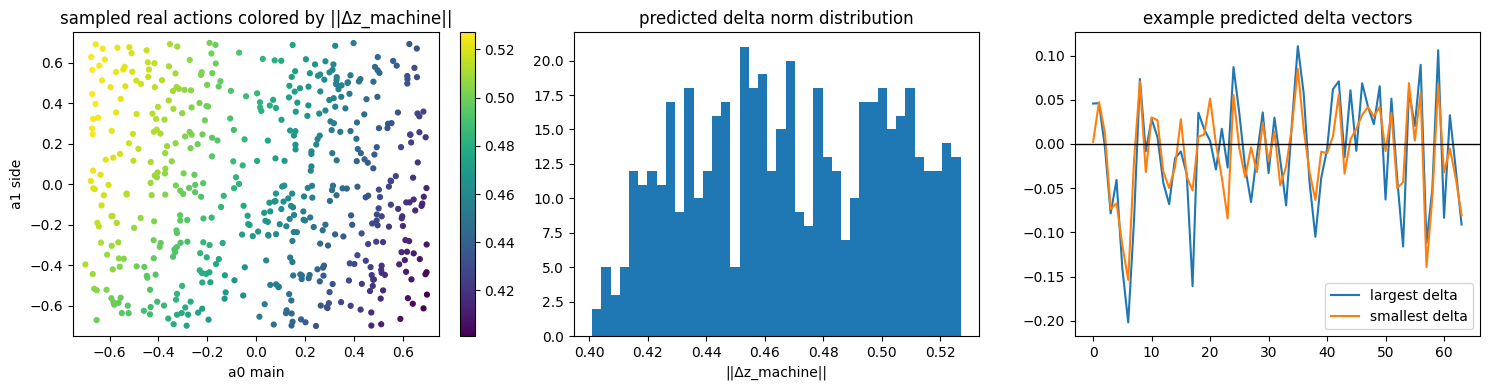

In [190]:
# Machine Forward visualization: real actions -> predicted latent delta strength.
acts = candidate_actions.detach().cpu().numpy()
delta_norms = candidate_deltas.norm(dim=-1).detach().cpu().numpy()

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
sc = axs[0].scatter(acts[:, 0], acts[:, 1], c=delta_norms, s=12, cmap="viridis")
axs[0].set_title("sampled real actions colored by ||Δz_machine||")
axs[0].set_xlabel("a0 main")
axs[0].set_ylabel("a1 side")
axs[0].set_xlim(-0.75, 0.75)
axs[0].set_ylim(-0.75, 0.75)
plt.colorbar(sc, ax=axs[0], fraction=0.046)

axs[1].hist(delta_norms, bins=40)
axs[1].set_title("predicted delta norm distribution")
axs[1].set_xlabel("||Δz_machine||")

axs[2].plot(candidate_deltas[delta_norms.argmax()].detach().cpu().numpy(), label="largest delta")
axs[2].plot(candidate_deltas[delta_norms.argmin()].detach().cpu().numpy(), label="smallest delta")
axs[2].axhline(0, color="black", lw=1)
axs[2].set_title("example predicted delta vectors")
axs[2].legend()

plt.tight_layout()
plt.show()

### 3.3 Runtime Control

| Intuitive description | Formula |
|---|---|
| Video Learner says what latent movement is desired. | $\Delta z^{desired}_{t+1}=FDM(c_t,IDM(c_t))$ |
| Runtime samples many real candidate actions. | $a^{(j)}\sim U(a_{low},a_{high})$ |
| Machine Forward predicts what each real action will do. | $\Delta z^{machine}_{t+s}(a^{(j)})=MF(H^{machine}_t,a^{(j)})$ |
| Pick the real action whose predicted latent movement best matches the desired movement. | $a_t^*=\arg\min_{a^{(j)}} \|\Delta z^{machine}_{t+s}(a^{(j)})-\alpha\Delta z^{desired}_{t+1}\|^2+\lambda\|a^{(j)}\|^2$ |
| Send selected action into LunarLander. | $o_{t+1},r_t=Env.step(a_t^*)$ |

Current suspected failure: the search can match latent movement while still choosing tiny real actions because the scale, stride horizon, and action penalty can bias the argmin toward action collapse.

In [191]:
ACTION_LOW = -0.7
ACTION_HIGH = 0.7
ACTION_L2_PENALTY = 0.05
DELTA_Z_SCALE = 1.5
N_RUNTIME_CANDIDATES = 8192

@torch.no_grad()
def runtime_choose_action(z_hist_input, desired_delta, n_candidates=N_RUNTIME_CANDIDATES):
    actions = torch.empty(n_candidates, 2, device=DEVICE).uniform_(ACTION_LOW, ACTION_HIGH)
    pred_delta = machine_forward_step(z_hist_input, actions)
    target = DELTA_Z_SCALE * desired_delta.expand_as(pred_delta)

    latent_loss = ((pred_delta - target) ** 2).mean(dim=-1)
    action_penalty = (actions ** 2).mean(dim=-1)
    total_loss = latent_loss + ACTION_L2_PENALTY * action_penalty
    best_idx = total_loss.argmin()

    return {
        "actions": actions,
        "pred_delta": pred_delta,
        "target": target,
        "latent_loss": latent_loss,
        "action_penalty": action_penalty,
        "total_loss": total_loss,
        "best_idx": best_idx,
        "best_action": actions[best_idx],
        "best_delta": pred_delta[best_idx],
    }

rt = runtime_choose_action(vl["z_hist"], vl["desired_delta"])
print("best action:", rt["best_action"].detach().cpu().numpy())
print("best action norm:", float(rt["best_action"].norm().detach().cpu()))
print("target delta norm:", float(rt["target"][0].norm().detach().cpu()))
print("best machine delta norm:", float(rt["best_delta"].norm().detach().cpu()))
print("best latent loss:", float(rt["latent_loss"][rt["best_idx"]].detach().cpu()))
print("best action penalty:", float(rt["action_penalty"][rt["best_idx"]].detach().cpu()))

best action: [ 0.03536012 -0.02098112]
best action norm: 0.041116245090961456
target delta norm: 0.19736488163471222
best machine delta norm: 0.47224563360214233
best latent loss: 0.004233916290104389
best action penalty: 0.0008452726760879159


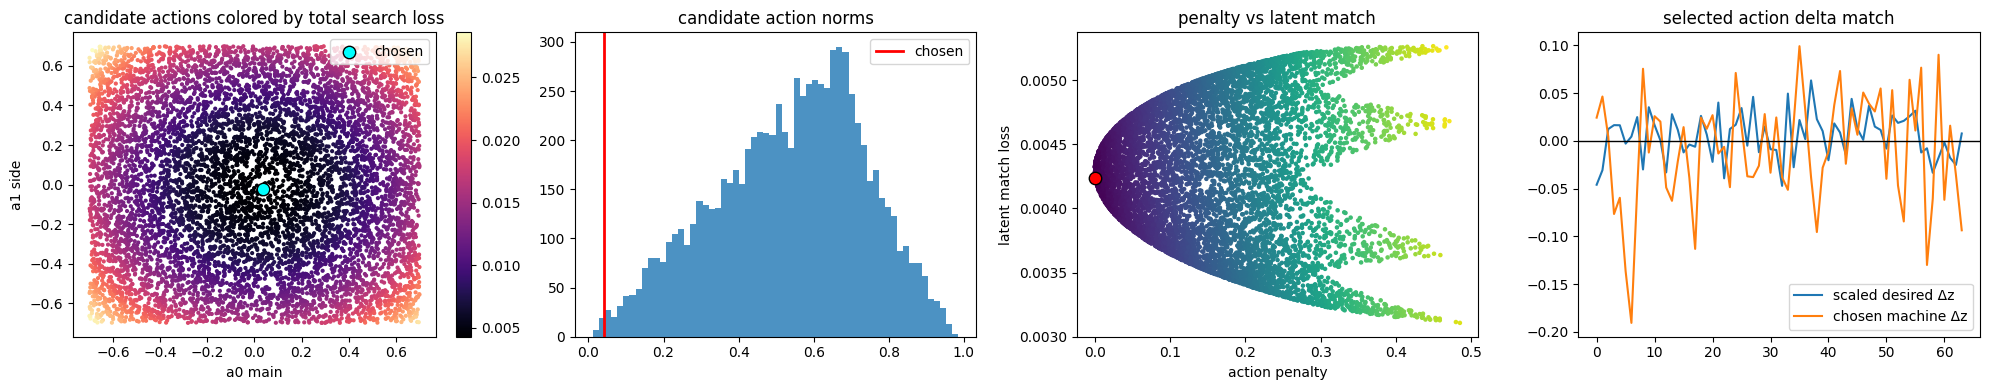

In [192]:
# Runtime Control visualization: where the selected action sits among candidates.
acts = rt["actions"].detach().cpu().numpy()
latent_loss = rt["latent_loss"].detach().cpu().numpy()
action_penalty = rt["action_penalty"].detach().cpu().numpy()
total_loss = rt["total_loss"].detach().cpu().numpy()
best = int(rt["best_idx"].detach().cpu())

fig, axs = plt.subplots(1, 4, figsize=(20, 4))

sc = axs[0].scatter(acts[:, 0], acts[:, 1], c=total_loss, s=4, cmap="magma")
axs[0].scatter(acts[best, 0], acts[best, 1], c="cyan", s=80, edgecolor="black", label="chosen")
axs[0].set_title("candidate actions colored by total search loss")
axs[0].set_xlabel("a0 main")
axs[0].set_ylabel("a1 side")
axs[0].legend()
plt.colorbar(sc, ax=axs[0], fraction=0.046)

axs[1].hist(np.linalg.norm(acts, axis=1), bins=60, alpha=0.8)
axs[1].axvline(np.linalg.norm(acts[best]), color="red", lw=2, label="chosen")
axs[1].set_title("candidate action norms")
axs[1].legend()

axs[2].scatter(action_penalty, latent_loss, c=total_loss, s=5, cmap="viridis")
axs[2].scatter(action_penalty[best], latent_loss[best], c="red", s=80, edgecolor="black")
axs[2].set_xlabel("action penalty")
axs[2].set_ylabel("latent match loss")
axs[2].set_title("penalty vs latent match")

axs[3].plot(rt["target"][0].detach().cpu().numpy(), label="scaled desired Δz")
axs[3].plot(rt["best_delta"].detach().cpu().numpy(), label="chosen machine Δz")
axs[3].axhline(0, color="black", lw=1)
axs[3].set_title("selected action delta match")
axs[3].legend()

plt.tight_layout()
plt.show()

## 4. What to debug next

Minimum checks before changing architecture:

1. Compare $\|a_t^*\|$ with candidate action norms.
2. Sweep $\lambda$ in $\lambda\|a\|^2$ and see if actions stop collapsing.
3. Sweep $\alpha$ in $\alpha\Delta z^{desired}_{t+1}$ because Machine Forward was trained on adaptive stride deltas.
4. Compare horizon mismatch: Video Learner asks for $t+1$, Machine Forward predicts $t+s$.
5. If search remains degenerate, replace argmin search with a learned `ActionDecoder(context, desired_delta) -> real_action` and use Machine Forward only as verifier/loss.